In [ ]:
%pip install hdbscan
%pip install hyperopt
%pip install umap
# and whatever else is missing

In [109]:
import hdbscan
import umap
from tqdm.notebook import trange
from hyperopt import fmin, tpe, hp, STATUS_OK, space_eval, Trials
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import openai

In [110]:
endpoint = "https://[...].openai.azure.com/"
api_key = "..."
model_embeddings = "text-embedding-ada-002"
model_completions = "gpt-4o"

client = openai.AzureOpenAI(
    azure_endpoint=endpoint,
    api_key=api_key,
    api_version="2024-06-01"
)


In [111]:
# calculate embeddings from a series of texts using openai
def get_embeddings(client, texts):
    embeddings = []
    for t in texts:
        response = client.embeddings.create(
            model=model_embeddings,
            input=t
        )
        embeddings.append(response.data[0].embedding)
    return embeddings

In [114]:
# read every line of input.txt and put it in an array
with open("input1.txt") as f:
    input = f.readlines()



In [116]:
# save embeddings to a file ( skip if embeddings are already there)
embeddings = get_embeddings(client, input)
with open("embeddings.txt", "w") as f:
    for e in embeddings:
        f.write(" ".join(map(str, e)) + "\n")

In [117]:
# read embeddings from a file
with open("embeddings.txt", "r") as f:
    embeddings = [list(map(float, line.strip().split())) for line in f]


In [118]:
def generate_clusters(message_embeddings,
                      n_neighbors,
                      n_components, 
                      min_cluster_size,
                      min_samples = None,
                      random_state = None):
    """
    Returns HDBSCAN objects after first performing dimensionality reduction using UMAP
    
    Arguments:
        message_embeddings: embeddings to use
        n_neighbors: int, UMAP hyperparameter n_neighbors
        n_components: int, UMAP hyperparameter n_components
        min_cluster_size: int, HDBSCAN hyperparameter min_cluster_size
        min_samples: int, HDBSCAN hyperparameter min_samples
        random_state: int, random seed
        
    Returns:
        clusters: HDBSCAN object of clusters
    """
    
    umap_embeddings = (umap.UMAP(n_neighbors = n_neighbors, 
                                n_components = n_components, 
                                metric = 'cosine', 
                                random_state=random_state)
                            .fit_transform(message_embeddings))

    clusters = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size, 
                               min_samples = min_samples,
                               metric='euclidean', 
                               gen_min_span_tree=True,
                               cluster_selection_method='eom').fit(umap_embeddings)
    
    return clusters

def objective(params, embeddings, label_lower, label_upper):
    """
    Objective function for hyperopt to minimize

    Arguments:
        params: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', 'random_state' and
               their values to use for evaluation
        embeddings: embeddings to use
        label_lower: int, lower end of range of number of expected clusters
        label_upper: int, upper end of range of number of expected clusters

    Returns:
        loss: cost function result incorporating penalties for falling
              outside desired range for number of clusters
        label_count: int, number of unique cluster labels, including noise
        status: string, hypoeropt status

        """
    
    clusters = generate_clusters(embeddings, 
                                 n_neighbors = params['n_neighbors'], 
                                 n_components = params['n_components'], 
                                 min_cluster_size = params['min_cluster_size'],
                                 random_state = params['random_state'])
    
    label_count, cost = score_clusters(clusters, prob_threshold = 0.05)
    
    #15% penalty on the cost function if outside the desired range of groups
    if (label_count < label_lower) | (label_count > label_upper):
        penalty = 0.15 
    else:
        penalty = 0
    
    loss = cost + penalty
    
    return {'loss': loss, 'label_count': label_count, 'status': STATUS_OK}

def bayesian_search(embeddings, space, label_lower, label_upper, max_evals=100):
    """
    Perform bayesian search on hyperparameter space using hyperopt

    Arguments:
        embeddings: embeddings to use
        space: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', and 'random_state' and
               values that use built-in hyperopt functions to define
               search spaces for each
        label_lower: int, lower end of range of number of expected clusters
        label_upper: int, upper end of range of number of expected clusters
        max_evals: int, maximum number of parameter combinations to try

    Saves the following to instance variables:
        best_params: dict, contains keys for 'n_neighbors', 'n_components',
               'min_cluster_size', 'min_samples', and 'random_state' and
               values associated with lowest cost scenario tested
        best_clusters: HDBSCAN object associated with lowest cost scenario
                       tested
        trials: hyperopt trials object for search

        """
    
    trials = Trials()
    fmin_objective = partial(objective, 
                             embeddings=embeddings, 
                             label_lower=label_lower,
                             label_upper=label_upper)
    
    best = fmin(fmin_objective, 
                space = space, 
                algo=tpe.suggest,
                max_evals=max_evals, 
                trials=trials)

    best_params = space_eval(space, best)
    print ('best:')
    print (best_params)
    print (f"label count: {trials.best_trial['result']['label_count']}")
    
    best_clusters = generate_clusters(embeddings, 
                                      n_neighbors = best_params['n_neighbors'], 
                                      n_components = best_params['n_components'], 
                                      min_cluster_size = best_params['min_cluster_size'],
                                      random_state = best_params['random_state'])
    
    return best_params, best_clusters, trials

def score_clusters(clusters, prob_threshold = 0.05):
    """
    Returns the label count and cost of a given clustering

    Arguments:
        clusters: HDBSCAN clustering object
        prob_threshold: float, probability threshold to use for deciding
                        what cluster labels are considered low confidence

    Returns:
        label_count: int, number of unique cluster labels, including noise
        cost: float, fraction of data points whose cluster assignment has
              a probability below cutoff threshold
    """
    
    cluster_labels = clusters.labels_
    label_count = len(np.unique(cluster_labels))
    total_num = len(clusters.labels_)
    cost = (np.count_nonzero(clusters.probabilities_ < prob_threshold)/total_num)
    
    return label_count, cost

def plot_clusters(embeddings, clusters, n_neighbors=15, min_dist=0.1):
    """
    Reduce dimensionality of best clusters and plot in 2D

    Arguments:
        embeddings: embeddings to use
        clusteres: HDBSCAN object of clusters
        n_neighbors: float, UMAP hyperparameter n_neighbors
        min_dist: float, UMAP hyperparameter min_dist for effective
                  minimum distance between embedded points

    """
    umap_data = umap.UMAP(n_neighbors=n_neighbors, 
                          n_components=2, 
                          min_dist = min_dist,  
                          #metric='cosine',
                          random_state=42).fit_transform(embeddings)

    point_size = 100.0 / np.sqrt(embeddings.shape[0])
    
    result = pd.DataFrame(umap_data, columns=['x', 'y'])
    result['labels'] = clusters.labels_

    fig, ax = plt.subplots(figsize=(14, 8))
    outliers = result[result.labels == -1]
    clustered = result[result.labels != -1]
    plt.scatter(outliers.x, outliers.y, color = 'lightgrey', s=point_size)
    plt.scatter(clustered.x, clustered.y, c=clustered.labels, s=point_size, cmap='jet')
    plt.colorbar()
    plt.show()

In [119]:
hspace = {
    "n_neighbors": hp.choice('n_neighbors', range(3,20)),
    "n_components": hp.choice('n_components', range(3,50)),
    "min_cluster_size": hp.choice('min_cluster_size', range(2,16)),
    "random_state": 42
}

label_lower = 30
label_upper = 100
max_evals = 100

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  1%|          | 1/100 [00:01<02:01,  1.22s/trial, best loss: 0.15]

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  2%|▏         | 2/100 [00:02<02:06,  1.29s/trial, best loss: 0.15]

...

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



100%|██████████| 100/100 [02:28<00:00,  1.49s/trial, best loss: 0.043333333333333335]

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



best:
{'min_cluster_size': 3, 'n_components': 29, 'n_neighbors': 4, 'random_state': 42}
label count: 32


c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


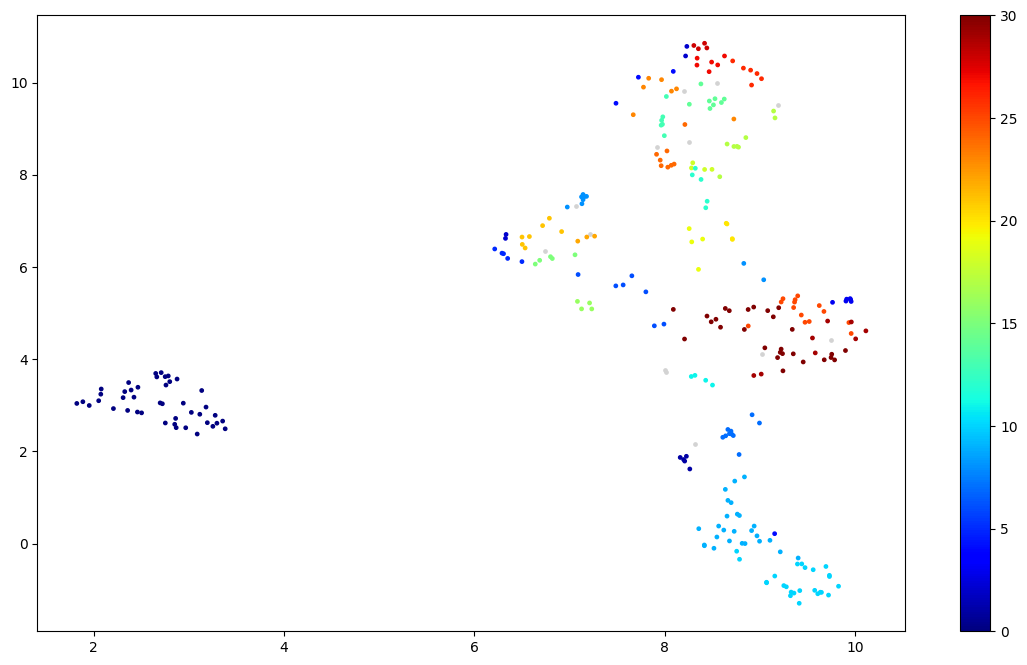

In [120]:
best_params_use, best_clusters_use, trials_use = bayesian_search(embeddings, 
                                                                 space=hspace, 
                                                                 label_lower=label_lower, 
                                                                 label_upper=label_upper, 
                                                                 max_evals=max_evals)

plot_clusters(np.array(embeddings), best_clusters_use, n_neighbors=15^0, min_dist=0.1)


c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Local\py311api\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


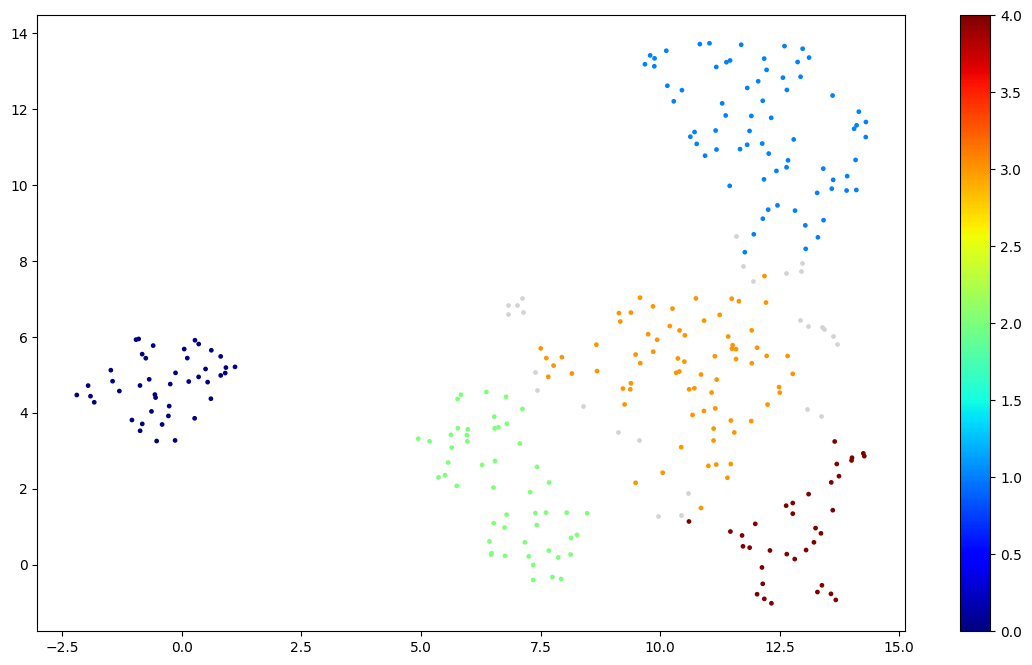

In [124]:
best_clusters = generate_clusters(embeddings, n_neighbors=5, n_components=5, min_cluster_size=10)

plot_clusters(np.array(embeddings), best_clusters, n_neighbors=5, min_dist=0.5)

In [85]:
def sample_sentiments_for_prompt(input, labels):
    dict = {}
    for idx, l in enumerate(input):
        label = labels[idx]
        if label > -1:
            if label in dict:
                dict[label].append(l)
            else:
                dict[label] = [l]   

    # print the dict in form of cluster ID: sentiment1, sentiment2, sentiment3, ...
    prompt = []
    for k, v in dict.items():
        prompt.append(f"--- Topic {k} ---")
        for i in v:
            prompt.append(f"{i.strip()}")

    return "\n".join(prompt)

def get_completions(client, query, max_tokens=1000):

    response = client.chat.completions.create(
        model=model_completions,
        response_format={ "type": "json_object" },
        messages=[
            {
            "role": "user",
            "content": [ {"type": "text", "text": query} ],
            },                
        ],
        max_tokens=max_tokens,
        )
    return response.choices[0].message.content

In [125]:
sentiments = sample_sentiments_for_prompt(input, best_clusters.labels_)

query = """ Here's the list of topics with their respective sentiments. 
Try to identify the specifics of each topic and make a suggestion as to how they should be called. Provide a reasoning for your decision.
Provide the answer in the following well-formed JSON format: 
-- example --
[
    { "id": 1, "name": "name1", "explanation": "explanation1" },
    { "id": 2, "name": "name2", "explanation": "explanation2" },
]
-- end of example --
%s
""" % sentiments
res = get_completions(client, query)
json.loads(res)


{'topics': [{'id': 0,
   'name': 'Cinema Experiences',
   'explanation': 'The topic discusses various individual experiences at the cinema, including both positive and negative aspects such as the quality of seating, screening formats, movie genres, and environmental factors.'},
  {'id': 1,
   'name': 'Dining Experiences',
   'explanation': 'The topic captures different experiences related to eating out, including the type of cuisine, service details, portion sizes, and overall satisfaction with meals at various eateries.'},
  {'id': 2,
   'name': 'Children’s Activities and Entertainment',
   'explanation': 'The topic is centered around children’s experiences at various entertainment venues within a mall, highlighting their enjoyment of activities, events, and any disappointments or inconveniences faced.'},
  {'id': 3,
   'name': 'Retail Discovery',
   'explanation': 'The topic explores the discovery of various retail stores, pop-up stands, and events within a mall, including unique fi